# 05 — Model Testing

Applies the configuration chosen in `04_model_training.ipynb` (per-exploration SVM-RBF classifiers, calibrated, and the Voting_AUC_Proba MoE ensemble) to the held-out test set: fits final models on the full training population, scores train/test/young-control, fuses via MoE, and reports AUC/F1/sensitivity/specificity. Ends with bootstrap/Wilson-interval uncertainty estimates on the held-out test set for reviewer response.

Part of the pipeline: 01 exploratory data analysis → 02 feature creation → 03 feature analysis → 04 model training → **05 (this notebook)**.


In [1]:
# Utilities
import os
import random
import pickle
import ast

# Data management
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Machine learning
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Custom utilities
from futils import compute_metrics


In [2]:
global_random_state = 42

explorations = ['Exploration_1', 'Exploration_2', 'Exploration_3', 'Exploration_4', 'Exploration_5', 'Exploration_6']

with open('../pkls/basic/group_labels.pkl', 'rb') as f:
    group_labels = pickle.load(f)

### Original train and test split (must stay identical to 01/02/04)
young_control_patients = group_labels[group_labels['group'] == 'young control']['patient_id'].tolist()
control_patients = group_labels[group_labels['group'] == 'control']['patient_id'].tolist()
pd_patients = group_labels[group_labels['group'] == 'PD']['patient_id'].tolist()

random.seed(42)
control_test = random.sample(control_patients, int(len(control_patients) * 0.2))
pd_test = random.sample(pd_patients, int(len(pd_patients) * 0.2))
test_patients = control_test + pd_test

modeling_patients = list(set(control_patients) | set(pd_patients) - set(test_patients))

# Chosen exploration-level models and MoE configuration, from 04_model_training.ipynb
chosen_models = pd.read_pickle('../pkls/model_performances/SVM_chosen_models.pkl')
moe_chosen_model = pd.read_pickle('../pkls/model_performances/SVM_moe_chosen_model.pkl')


In [3]:
chosen_models

,exploration,dataset,kernel,C,gamma,k,class_weight_ratio,mean_test_accuracy,sd_test_accuracy,mean_test_precision,sd_test_precision,mean_test_sensitivity,sd_test_sensitivity,mean_test_specificity,sd_test_specificity,mean_test_f1,sd_test_f1,mean_test_roc_auc,sd_test_roc_auc,mean_test_youdens_j,sd_test_youdens_j
0,Exploration_1,fixsac+state,rbf,1.00,0.01,6,1,0.66,0.09,0.65,0.19,0.67,0.22,0.68,0.20,0.62,0.13,0.74,0.10,0.34,0.20
1,Exploration_2,fixsac+state,rbf,1.00,0.01,24,1,0.69,0.08,0.59,0.20,0.78,0.22,0.64,0.15,0.65,0.17,0.78,0.11,0.42,0.21
2,Exploration_3,fixsac+state,rbf,1.00,0.01,49,1,0.58,0.12,0.53,0.24,0.39,0.15,0.73,0.15,0.43,0.16,0.60,0.12,0.12,0.22
3,Exploration_4,fixsac+state,rbf,1.00,0.01,8,1,0.64,0.10,0.58,0.21,0.63,0.20,0.68,0.14,0.57,0.15,0.70,0.12,0.31,0.22
4,Exploration_5,fixsac+state,rbf,1.00,0.01,42,1,0.62,0.09,0.61,0.21,0.52,0.20,0.74,0.17,0.51,0.13,0.65,0.10,0.26,0.14
5,Exploration_6,fixsac+state,rbf,1.00,0.01,10,1,0.65,0.13,0.61,0.19,0.66,0.19,0.67,0.17,0.60,0.14,0.69,0.16,0.33,0.23


In [4]:
moe_chosen_model

,model,variables_used,parameters,threshold,auc_mean,auc_sd,f1_mean,f1_sd,accuracy_mean,accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,youdens_j_mean,youdens_j_sd
0,Voting_AUC_Proba,"['Exploration_4_proba_eye1', 'Exploration_1_proba_eye1', 'Exploration_2_proba_eye2']",NA,0.40,0.84,0.07,0.73,0.10,0.77,0.08,0.87,0.08,0.71,0.12,0.58,0.14


In [5]:
###### Fixation-saccade metrics ######
with open('../pkls/metrics/fixation_saccade_metrics.pkl', 'rb') as f:
    sacfix_metrics = pickle.load(f)

###### GMM (state based) metrics ######
with open('../pkls/metrics/gmm_metrics.pkl', 'rb') as f:
    gmm_metrics = pickle.load(f)

###### Join all metrics into dataframe ######
sacfix_gmm_metrics = pd.merge(
    gmm_metrics, sacfix_metrics,
    on=['patient_id', 'exploration_id', 'eye', 'group', 'group_general']
)
sacfix_gmm_metrics['target'] = (sacfix_gmm_metrics['group_general'] == 'PD').astype(int)


## Fit Final Models and Score Train / Test / Young Control

In [6]:
predictions_pre_moe = pd.DataFrame(columns=["patient_id", "exploration_id", "proba", "score", "group_model"])
feature_importances_pre_moe = pd.DataFrame(columns=["exploration_id", "feature", "importance"])

svm_trained_models = {}

for exploration in explorations:
    print(f"Processing Exploration: {exploration}")

    model_info = chosen_models[chosen_models['exploration'] == exploration]
    k = int(model_info['k'].values[0])
    kernel = str(model_info['kernel'].values[0]).lower()
    C = float(model_info['C'].values[0])
    if C == 0:
        C = 1e-10  # avoid C=0 error

    gamma = model_info['gamma'].values[0]  # only used if kernel == "rbf"

    class_weight_ratio = float(model_info['class_weight_ratio'].values[0])
    class_weight = {0: 1.0, 1: class_weight_ratio}

    svc_kwargs = {"kernel": kernel, "C": C, "probability": False, "class_weight": class_weight}
    if kernel == "rbf":
        svc_kwargs["gamma"] = gamma

    base_model = SVC(**svc_kwargs)
    cal_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=global_random_state)
    model = CalibratedClassifierCV(estimator=base_model, method="sigmoid", cv=cal_cv)

    df = sacfix_gmm_metrics[sacfix_gmm_metrics['exploration_id'] == exploration].copy()
    df = df[df['k_clusters'] == k]
    df.drop(['k_clusters'], axis=1, inplace=True)

    df_train = df[df['patient_id'].isin(modeling_patients)]

    df_train_pivoted = df_train.pivot_table(
        index=['patient_id', 'eye', 'target', 'group', 'group_general', 'exploration_id',
               'total_saccades', 'total_saccadic_excursion', 'total_fixations',
               'average_fixation_time', 'total_scanned_area', 'longest_diagonal'],
        columns='state', values=['FO', 'MLT', 'MIL', 'entropy'], aggfunc='first'
    )
    df_train_pivoted.columns = [f'{metric}_state_{state}' for metric, state in df_train_pivoted.columns]
    df_train_pivoted = df_train_pivoted.reset_index()
    df_train_pivoted.fillna(0, inplace=True)

    for prefix in ['FO', 'MLT', 'MIL', 'entropy']:
        cols = [c for c in df_train_pivoted.columns if prefix in c]
        df_train_pivoted[f'max_{prefix}'] = df_train_pivoted[cols].max(axis=1)
        df_train_pivoted[f'min_{prefix}'] = df_train_pivoted[cols].min(axis=1)

    feature_cols = df_train_pivoted.drop(
        ['patient_id', 'exploration_id', 'eye', 'group', 'group_general', 'target'], axis=1
    ).columns

    X_train = df_train_pivoted[feature_cols].values
    y_train = df_train_pivoted['target'].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    model.fit(X_train_scaled, y_train)

    svm_trained_models[exploration] = {
        "model": model, "scaler": scaler, "feature_cols": list(feature_cols),
        "k": k, "kernel": kernel, "C": C, "gamma": gamma if kernel == "rbf" else None,
        "class_weight_ratio": class_weight_ratio, "class_weight": class_weight
    }

    ## Train patients
    y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]

    ## Test patients
    df_test = df[df['patient_id'].isin(test_patients)]
    df_test_pivoted = df_test.pivot_table(
        index=['patient_id', 'eye', 'target', 'group', 'group_general', 'exploration_id',
               'total_saccades', 'total_saccadic_excursion', 'total_fixations',
               'average_fixation_time', 'total_scanned_area', 'longest_diagonal'],
        columns='state', values=['FO', 'MLT', 'MIL', 'entropy'], aggfunc='first'
    )
    df_test_pivoted.columns = [f'{metric}_state_{state}' for metric, state in df_test_pivoted.columns]
    df_test_pivoted = df_test_pivoted.reset_index()
    df_test_pivoted.fillna(0, inplace=True)
    for prefix in ['FO', 'MLT', 'MIL', 'entropy']:
        cols = [c for c in df_test_pivoted.columns if prefix in c]
        df_test_pivoted[f'max_{prefix}'] = df_test_pivoted[cols].max(axis=1)
        df_test_pivoted[f'min_{prefix}'] = df_test_pivoted[cols].min(axis=1)

    X_test = df_test_pivoted[feature_cols].values
    X_test_scaled = scaler.transform(X_test)
    y_test = df_test_pivoted['target'].values
    y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    ## Young control patients
    df_young_control = df[df['patient_id'].isin(young_control_patients)]
    df_young_control_pivoted = df_young_control.pivot_table(
        index=['patient_id', 'eye', 'target', 'group', 'group_general', 'exploration_id',
               'total_saccades', 'total_saccadic_excursion', 'total_fixations',
               'average_fixation_time', 'total_scanned_area', 'longest_diagonal'],
        columns='state', values=['FO', 'MLT', 'MIL', 'entropy'], aggfunc='first'
    )
    df_young_control_pivoted.columns = [f'{metric}_state_{state}' for metric, state in df_young_control_pivoted.columns]
    df_young_control_pivoted = df_young_control_pivoted.reset_index()
    df_young_control_pivoted.fillna(0, inplace=True)
    for prefix in ['FO', 'MLT', 'MIL', 'entropy']:
        cols = [c for c in df_young_control_pivoted.columns if prefix in c]
        df_young_control_pivoted[f'max_{prefix}'] = df_young_control_pivoted[cols].max(axis=1)
        df_young_control_pivoted[f'min_{prefix}'] = df_young_control_pivoted[cols].min(axis=1)

    X_young_control = df_young_control_pivoted[feature_cols].values
    X_young_control_scaled = scaler.transform(X_young_control)
    y_young_control_pred_proba = model.predict_proba(X_young_control_scaled)[:, 1]

    train_predictions = pd.DataFrame({
        "patient_id": df_train_pivoted["patient_id"], "exploration_id": df_train_pivoted["exploration_id"],
        "proba": y_train_pred_proba, "group_model": "train"
    })
    test_predictions = pd.DataFrame({
        "patient_id": df_test_pivoted["patient_id"], "exploration_id": df_test_pivoted["exploration_id"],
        "proba": y_test_pred_proba, "group_model": "test"
    })
    young_control_predictions = pd.DataFrame({
        "patient_id": df_young_control_pivoted["patient_id"], "exploration_id": df_young_control_pivoted["exploration_id"],
        "proba": y_young_control_pred_proba, "group_model": "young_control"
    })

    all_predictions = pd.concat([train_predictions, test_predictions, young_control_predictions], ignore_index=True)
    predictions_pre_moe = pd.concat([predictions_pre_moe, all_predictions], ignore_index=True)

    ######### feature importances / coefficients
    if kernel == "linear":
        linear_est = model.estimator
        if hasattr(linear_est, "calibrated_classifiers_") and len(linear_est.calibrated_classifiers_) > 0:
            svc_est = linear_est.calibrated_classifiers_[0].estimator
            feature_importances = svc_est.coef_.ravel()
        else:
            feature_importances = np.zeros(len(feature_cols))
    else:
        result = permutation_importance(model, X_test_scaled, y_test, scoring="accuracy", n_repeats=10, random_state=42)
        feature_importances = result.importances_mean

    feature_importances_df = pd.DataFrame({
        "exploration_id": [exploration] * len(feature_cols), "feature": feature_cols, "importance": feature_importances
    })
    feature_importances_pre_moe = pd.concat([feature_importances_pre_moe, feature_importances_df], ignore_index=True)

os.makedirs('../pkls/model_performances/', exist_ok=True)
with open('../pkls/model_performances/SVM_trained_models.pkl', 'wb') as f:
    pickle.dump(svm_trained_models, f)


Processing Exploration: Exploration_1


<local path> FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  predictions_pre_moe = pd.concat([predictions_pre_moe, all_predictions], ignore_index=True)


<local path> FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  feature_importances_pre_moe = pd.concat([feature_importances_pre_moe, feature_importances_df], ignore_index=True)


Processing Exploration: Exploration_2


Processing Exploration: Exploration_3


Processing Exploration: Exploration_4


Processing Exploration: Exploration_5


Processing Exploration: Exploration_6


In [7]:
predictions_pre_moe = pd.merge(predictions_pre_moe, group_labels, on="patient_id", how="left")
predictions_pre_moe['target'] = (predictions_pre_moe['group_general'] == 'PD').astype(int)
predictions_pre_moe['prediction'] = (predictions_pre_moe['proba'] > 0.5).astype(int)

predictions_pre_moe.head()


[output removed: contained participant-level rows. Re-run the notebook against your own copy of the recordings to regenerate it.]

In [8]:
# create intermediate metrics performance check, per exploration_id
performance_metrics_pre_moe_train = predictions_pre_moe[predictions_pre_moe['group_model'] == 'train'].groupby("exploration_id").apply(compute_metrics, include_groups=False).reset_index()
performance_metrics_pre_moe_test = predictions_pre_moe[predictions_pre_moe['group_model'] == 'test'].groupby("exploration_id").apply(compute_metrics, include_groups=False).reset_index()

print("Train metrics:\n")
print(performance_metrics_pre_moe_train)
print("\nTest metrics:\n")
print(performance_metrics_pre_moe_test)


Train metrics:

  exploration_id  accuracy  sensitivity  specificity  auc   f1
0  Exploration_1      0.81         0.74         0.88 0.88 0.78
1  Exploration_2      0.99         0.98         1.00 1.00 0.99
2  Exploration_3      1.00         1.00         1.00 1.00 1.00
3  Exploration_4      0.86         0.77         0.92 0.92 0.81
4  Exploration_5      1.00         1.00         1.00 1.00 1.00
5  Exploration_6      0.88         0.83         0.92 0.97 0.86

Test metrics:

  exploration_id  accuracy  sensitivity  specificity  auc   f1
0  Exploration_1      0.75         0.67         0.86 0.74 0.75
1  Exploration_2      0.74         0.50         1.00 0.89 0.67
2  Exploration_3      0.56         0.12         1.00 1.00 0.22
3  Exploration_4      0.83         0.67         1.00 0.87 0.80
4  Exploration_5      0.71         0.44         1.00 1.00 0.62
5  Exploration_6      0.79         0.71         0.86 0.93 0.77


In [9]:
# create an increasing variable for eye: 1,2 (max) for each patient, exploration_id combination
predictions_pre_moe["eye"] = predictions_pre_moe.groupby(["patient_id", "group_model", "exploration_id"]).cumcount() + 1

# pivot into Exploration_X_proba_eyeY columns
predictions_pre_moe = predictions_pre_moe.pivot_table(
    index=["patient_id", "group_model"], columns=["exploration_id", "eye"], values="proba", aggfunc="first"
)
predictions_pre_moe.columns = [f"{exp}_proba_eye{eye}" for exp, eye in predictions_pre_moe.columns]
predictions_pre_moe.reset_index(inplace=True)

# most patients have complete data; missing values are input as 0.5 in all cases
predictions_pre_moe.fillna(0.5, inplace=True)

predictions_pre_moe = pd.merge(predictions_pre_moe, group_labels, on="patient_id", how="left")
predictions_pre_moe['target'] = (predictions_pre_moe['group_general'] == 'PD').astype(int)

predictions_pre_moe.head()


[output removed: contained participant-level rows. Re-run the notebook against your own copy of the recordings to regenerate it.]

## Mix the Experts

In [10]:
# 1) Which approach, which features, and which threshold do we use?
moe_model_type = moe_chosen_model['model'].iloc[0]
variables_used = ast.literal_eval(moe_chosen_model['variables_used'].iloc[0])
moe_threshold = float(moe_chosen_model['threshold'].iloc[0])

# 2) Our base predictions already have everything:
#    patient_id, group_model, per-exploration proba cols, group, group_general, target
base = predictions_pre_moe.copy()

# 3A) LOGISTIC MoE branch
if moe_model_type.startswith("Logistic"):
    if moe_model_type == "Logistic_None":
        model = LogisticRegression(penalty=None, solver="lbfgs")
    elif moe_model_type == "Logistic_L1":
        model = LogisticRegression(penalty="l1", solver="liblinear")
    elif moe_model_type == "Logistic_L2":
        model = LogisticRegression(penalty="l2", solver="lbfgs")
    else:
        raise ValueError(f"Unknown MoE model type: {moe_model_type}")

    df_tr = base[base['group_model'] == "train"]
    df_te = base[base['group_model'] == "test"]
    df_yc = base[base['group_model'] == "young_control"]

    model.fit(df_tr[variables_used], df_tr['target'])

    def predict_split(df_split):
        proba = model.predict_proba(df_split[variables_used])[:, 1]
        pred = (proba > moe_threshold).astype(int)
        return pd.DataFrame({
            'patient_id': df_split['patient_id'], 'proba': proba, 'score': proba,
            'group_model': df_split['group_model'], 'prediction': pred,
            'group': df_split['group'], 'group_general': df_split['group_general'], 'target': df_split['target']
        })

    predictions_post_moe = pd.concat([predict_split(df_tr), predict_split(df_te), predict_split(df_yc)], ignore_index=True)

# 3B) VOTING MoE branch
elif moe_model_type in ("Voting_Equal_Proba", "Voting_AUC_Proba"):
    scheme = moe_model_type.split("_")[1].lower()  # 'equal' or 'auc'
    df = base.copy()
    proba_cols = [c for c in variables_used if c in df.columns]

    if scheme == "equal":
        weights = np.ones(len(proba_cols)) / len(proba_cols)
    else:  # 'auc'
        auc_map = chosen_models.set_index('exploration')['mean_test_roc_auc'].to_dict()
        weights = np.array([auc_map[col.split("_proba_")[0]] for col in proba_cols], dtype=float)
        weights /= weights.sum()

    df['proba'] = df[proba_cols].values.dot(weights)
    df['score'] = df['proba']
    df['prediction'] = (df['proba'] > moe_threshold).astype(int)

    predictions_post_moe = df[['patient_id', 'proba', 'score', 'group_model', 'prediction', 'group', 'group_general', 'target']].reset_index(drop=True)

else:
    raise ValueError(f"Unknown MoE model type: {moe_model_type}")

predictions_post_moe.head()


[output removed: contained participant-level rows. Re-run the notebook against your own copy of the recordings to regenerate it.]

## Final Performance Metrics

In [11]:
performance_metrics = predictions_post_moe.groupby("group_model").apply(compute_metrics).reset_index()
performance_metrics = performance_metrics[performance_metrics['group_model'].isin(['train', 'test'])]
performance_metrics


<local path> UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
<local path> UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
<local path> DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  performance_metrics = predictions_post_moe.groupby("group_model").apply(compute_metrics).reset_index()


,group_model,accuracy,sensitivity,specificity,auc,f1
0,test,0.89,0.78,1.00,0.84,0.88
1,train,0.98,0.97,0.98,1.00,0.97


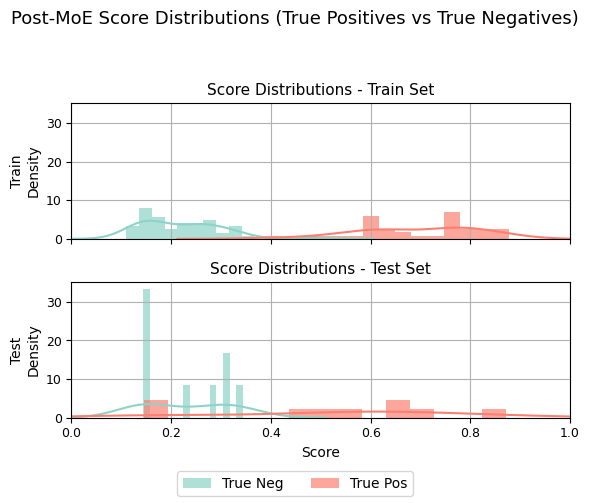

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True, sharey=True)
colors = {0: '#8dd3c7', 1: '#fb8072'}

for i, group_model in enumerate(['train', 'test']):
    ax = axes[i]
    ax.set_xlim(0, 1)
    subset = predictions_post_moe[predictions_post_moe['group_model'] == group_model]

    for label in [0, 1]:
        label_name = f"{'True Neg' if label == 0 else 'True Pos'}"
        label_data = subset[subset['target'] == label]['score']
        ax.hist(label_data, bins=15, density=True, alpha=0.7, color=colors[label], label=label_name if i == 0 else None)
        sns.kdeplot(x=label_data, ax=ax, fill=False, linewidth=1.5, color=colors[label], alpha=1)

    ax.set_ylabel(f"{group_model.capitalize()}\nDensity", fontsize=10)
    ax.set_xlabel("Score", fontsize=10)
    ax.set_title(f"Score Distributions - {group_model.capitalize()} Set", fontsize=11)
    ax.tick_params(labelsize=9)
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10)
fig.suptitle("Post-MoE Score Distributions (True Positives vs True Negatives)", fontsize=13)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("../plots/paper_figures/moe_score_distributions.png")
plt.show()


## Uncertainty of the held-out AUC

Confidence interval for the patient-level AUC on the held-out test set. The reported
interval uses the DeLong standard error, the standard non-parametric estimator for the
variance of a single AUC. The Hanley-McNeil closed form and a stratified bootstrap are
computed alongside it as cross-checks. All three use the same post-MoE scores as the
metrics reported above.

In [ ]:
import math
from sklearn.metrics import roc_auc_score

test = predictions_post_moe[predictions_post_moe['group_model'] == 'test']
y = test['target'].values.astype(int)
s = test['score'].values
pos, neg = s[y == 1], s[y == 0]
n1, n2 = len(pos), len(neg)
auc = roc_auc_score(y, s)

print(f"Held-out participants scored: {n1 + n2}  ({n1} PD, {n2} HC)")
print(f"AUC = {auc:.4f}")
print()

# --- DeLong standard error (single AUC, via placement values) ---
psi = lambda a, b: (a > b) * 1.0 + (a == b) * 0.5
v10 = np.array([psi(p, neg).mean() for p in pos])   # one per positive
v01 = np.array([psi(pos, n).mean() for n in neg])   # one per negative
se_delong = math.sqrt(v10.var(ddof=1) / n1 + v01.var(ddof=1) / n2)

# --- Hanley-McNeil standard error (closed form; needs only AUC, n1, n2) ---
q1 = auc / (2 - auc)
q2 = 2 * auc ** 2 / (1 + auc)
se_hm = math.sqrt(
    (auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n2 - 1) * (q2 - auc ** 2)) / (n1 * n2)
)

for name, se in [("DeLong", se_delong), ("Hanley-McNeil", se_hm)]:
    lo, hi = auc - 1.96 * se, auc + 1.96 * se
    print(f"{name:15s} SE = {se:.4f}   95% CI = {max(0.0, lo):.2f} - {min(1.0, hi):.2f}"
          f"{'  (upper bound truncated at 1)' if hi > 1 else ''}")

# --- Stratified bootstrap percentile interval ---
rng = np.random.default_rng(global_random_state)
boot = np.array([
    roc_auc_score(
        np.r_[np.ones(n1), np.zeros(n2)],
        np.r_[rng.choice(pos, n1, replace=True), rng.choice(neg, n2, replace=True)]
    )
    for _ in range(10000)
])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"{'Bootstrap':15s} SD = {boot.std(ddof=1):.4f}   95% CI = {lo:.2f} - {hi:.2f}  (10,000 replicates)")